In [ ]:
# 1 EDA CARGA Y EXPLORACION DE DATOS

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns




print(pd.__version__)
print(np.__version__)



3.0.6
2.5.3


In [6]:
df_restaurantes = pd.read_csv('C:\\Users\\magri\\Downloads\\base_datos_restaurantes_USA_v2.csv')

In [7]:
print("1.1---primeras 5 filas de la tabla")
display(df_restaurantes.head())

print("\n1.2---información sobre la estructura de la tabla")
display(df_restaurantes.info())

print("\n1.3---Descripcion del dataframe")
display(df_restaurantes.describe())



1.1---primeras 5 filas de la tabla


,id_persona,nombre,apellido,edad,genero,ciudad_residencia,estrato_socioeconomico,frecuencia_visita,promedio_gasto_comida,ocio,consume_licor,preferencias_alimenticias,membresia_premium,telefono_contacto,correo_electronico,tipo_de_pago_mas_usado,ingresos_mensuales
0,2550327378,Jackson,Gomez,31.0,Masculino,Miami,Alto,6,67.51,Sí,No,Vegetariano,Sí,(830)220-1926,NaN,Efectivo,6425
1,9446112038,Samantha,Soto,40.0,Femenino,Denver,Medio,2,44.92,Sí,Sí,Mariscos,No,881-476-1426,NaN,Efectivo,2374
2,3098363243,Terry,Adams,62.0,Femenino,Denver,Bajo,2,9.24,Sí,Sí,Vegetariano,No,NaN,diana74@example.net,Efectivo,1110
3,4013002847,James,Shannon,41.0,Masculino,Boston,Alto,5,30.74,Sí,Sí,Carnes,Sí,NaN,scottfrey@example.com,Tarjeta,6931
4,7372911048,Susan,Jones,49.0,Femenino,San Diego,Bajo,0,0.00,No,No,Carnes,No,243.248.8919,glassgary@example.org,Tarjeta,1350



1.2---información sobre la estructura de la tabla
<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_persona                 30000 non-null  int64  
 1   nombre                     30000 non-null  str    
 2   apellido                   30000 non-null  str    
 3   edad                       29899 non-null  float64
 4   genero                     30000 non-null  str    
 5   ciudad_residencia          30000 non-null  str    
 6   estrato_socioeconomico     30000 non-null  str    
 7   frecuencia_visita          30000 non-null  int64  
 8   promedio_gasto_comida      29855 non-null  float64
 9   ocio                       30000 non-null  str    
 10  consume_licor              30000 non-null  str    
 11  preferencias_alimenticias  28597 non-null  str    
 12  membresia_premium          30000 non-null  str    
 13  telefo

None


1.3---Descripcion del dataframe


,id_persona,edad,frecuencia_visita,promedio_gasto_comida,ingresos_mensuales
count,3.000000e+04,29899.000000,30000.000000,29855.000000,30000.000000
mean,5.504765e+09,49.665006,3.896133,32.603452,5389.755867
std,2.602799e+09,23.839550,2.741532,26.402601,4538.491728
min,1.000153e+09,-5.000000,-3.000000,0.000000,800.000000
25%,3.243617e+09,33.000000,2.000000,13.290000,1860.000000
50%,5.515865e+09,49.000000,4.000000,25.510000,3402.000000
75%,7.754426e+09,65.000000,5.000000,44.400000,7761.000000
max,9.999627e+09,300.000000,10.000000,149.970000,17999.000000


In [ ]:
#2. Limpieza y transformación de datos

In [8]:
df_restaurantes_trans = df_restaurantes.copy()

In [9]:
df_restaurantes_trans.isnull().sum().sort_values(ascending=False)


telefono_contacto            15166
correo_electronico           15072
preferencias_alimenticias     1403
promedio_gasto_comida          145
edad                           101
id_persona                       0
genero                           0
apellido                         0
nombre                           0
frecuencia_visita                0
estrato_socioeconomico           0
ciudad_residencia                0
ocio                             0
membresia_premium                0
consume_licor                    0
tipo_de_pago_mas_usado           0
ingresos_mensuales               0
dtype: int64

In [ ]:
#2.1 Limpieza de la edad

In [10]:
df_restaurantes_trans['edad'] = df_restaurantes_trans['edad'].apply(lambda x: x if (18 < x <100) else None)

In [11]:
df_restaurantes_trans.isnull().sum().sort_values(ascending=False)


telefono_contacto            15166
correo_electronico           15072
preferencias_alimenticias     1403
edad                           765
promedio_gasto_comida          145
id_persona                       0
genero                           0
apellido                         0
nombre                           0
frecuencia_visita                0
estrato_socioeconomico           0
ciudad_residencia                0
ocio                             0
membresia_premium                0
consume_licor                    0
tipo_de_pago_mas_usado           0
ingresos_mensuales               0
dtype: int64

In [12]:
edad_promedio_group = df_restaurantes_trans.groupby(['ciudad_residencia'])['edad'].median()

display(edad_promedio_group)


ciudad_residencia
Boston       49.0
Chicago      49.0
Dallas       50.0
Denver       50.0
Houston      49.0
Miami        49.0
NYC          49.0
Phoenix      49.0
San Diego    50.0
Seattle      50.0
Name: edad, dtype: float64

In [13]:
edad_pgroup_f = df_restaurantes_trans.groupby(['ciudad_residencia','estrato_socioeconomico'])['edad'].transform('median')



In [14]:
df_restaurantes_trans['edad'] = df_restaurantes_trans['edad'].fillna(edad_pgroup_f)

In [15]:
df_restaurantes_trans.isnull().sum().sort_values(ascending=False)

telefono_contacto            15166
correo_electronico           15072
preferencias_alimenticias     1403
promedio_gasto_comida          145
id_persona                       0
genero                           0
nombre                           0
edad                             0
apellido                         0
frecuencia_visita                0
estrato_socioeconomico           0
ciudad_residencia                0
ocio                             0
membresia_premium                0
consume_licor                    0
tipo_de_pago_mas_usado           0
ingresos_mensuales               0
dtype: int64

In [ ]:
#3 Limpieza de datos por preferencia alimenticias


In [17]:
df_restaurantes_trans['preferencias_alimenticias'].value_counts()
df_restaurantes_trans.groupby(['ciudad_residencia', 'preferencias_alimenticias']).size()

ciudad_residencia  preferencias_alimenticias
Boston             Carnes                        535
                   Mariscos                      493
                   Otro                          198
                   Pescado                       272
                   Vegano                        239
                   Vegetariano                   708
Chicago            Carnes                       1589
                   Mariscos                      696
                   Otro                          591
                   Pescado                       546
                   Vegano                        571
                   Vegetariano                  1123
Dallas             Carnes                        822
                   Mariscos                      366
                   Otro                          249
                   Pescado                       239
                   Vegano                        258
                   Vegetariano                   539
D

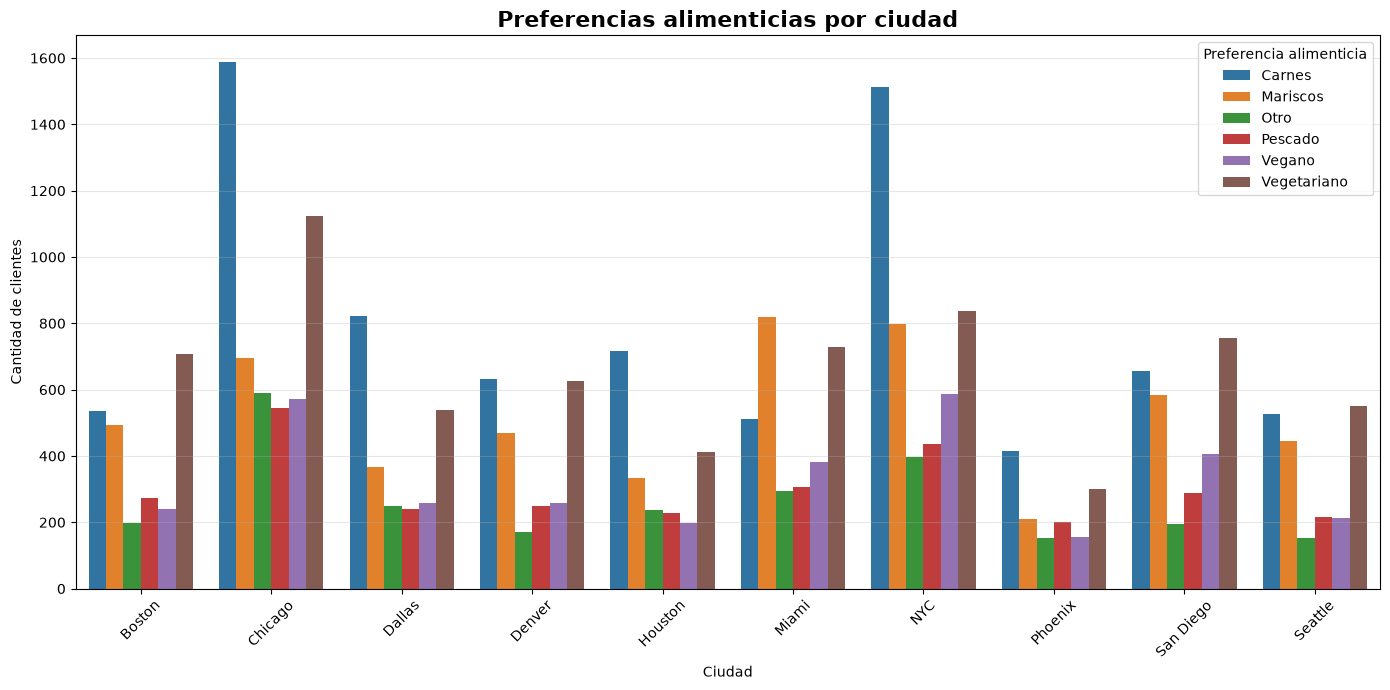

In [18]:
df_preferencias = (
    df_restaurantes_trans
    .groupby(["ciudad_residencia", "preferencias_alimenticias"])
    .size()
    .reset_index(name="cantidad")
)

plt.figure(figsize=(14, 7))

sns.barplot(
    data=df_preferencias,
    x="ciudad_residencia",
    y="cantidad",
    hue="preferencias_alimenticias"
)

plt.title("Preferencias alimenticias por ciudad", fontsize=16, fontweight="bold")
plt.xlabel("Ciudad")
plt.ylabel("Cantidad de clientes")

plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.legend(title="Preferencia alimenticia")
plt.tight_layout()
plt.show()

In [19]:
preferencia_group = df_restaurantes_trans.groupby(
    'ciudad_residencia')['preferencias_alimenticias'].transform(lambda x: x.mode()[0])

In [20]:
df_restaurantes_trans['preferencias_alimenticias'].value_counts()

preferencias_alimenticias
Carnes         7916
Vegetariano    6580
Mariscos       5212
Vegano         3267
Pescado        2983
Otro           2639
Name: count, dtype: int64

In [ ]:
#4. Cantidad de clientes por ciudad 

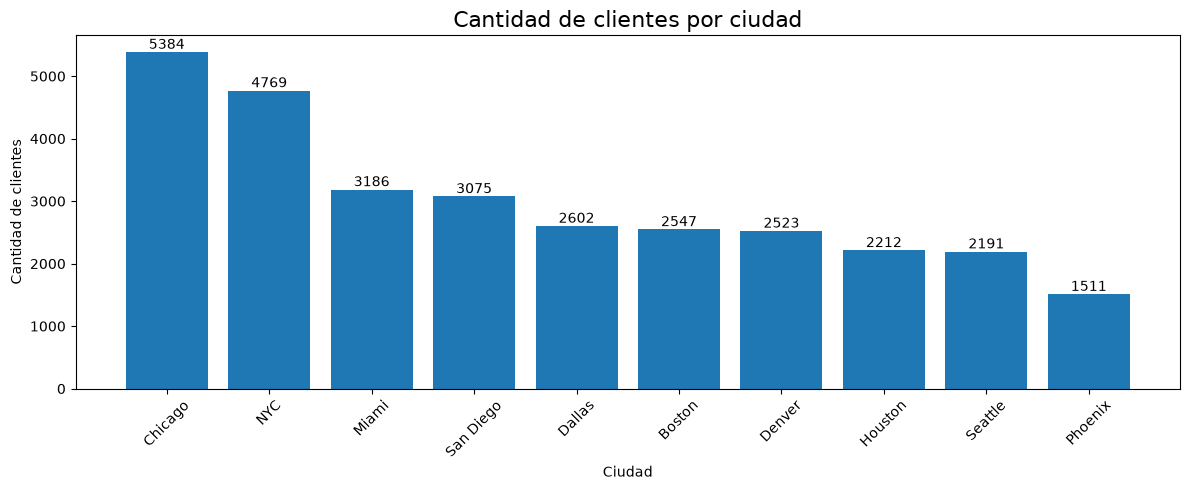

In [21]:
df_clientes_por_ciudad = df_restaurantes.groupby("ciudad_residencia")["id_persona"].count().reset_index()

df_clientes_por_ciudad = df_clientes_por_ciudad.sort_values(
    by="id_persona",
    ascending=False
)

plt.figure(figsize=(12, 5))

barras = plt.bar(
    df_clientes_por_ciudad["ciudad_residencia"],
    df_clientes_por_ciudad["id_persona"]
)

plt.title("Cantidad de clientes por ciudad", fontsize=16)
plt.xlabel("Ciudad")
plt.ylabel("Cantidad de clientes")

plt.bar_label(barras)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [22]:
df_clientes_por_ciudad

,ciudad_residencia,id_persona
1,Chicago,5384
6,NYC,4769
5,Miami,3186
8,San Diego,3075
2,Dallas,2602
0,Boston,2547
3,Denver,2523
4,Houston,2212
9,Seattle,2191
7,Phoenix,1511


In [23]:
df_restaurantes_trans.isnull().sum().sort_values(ascending=False)

telefono_contacto            15166
correo_electronico           15072
preferencias_alimenticias     1403
promedio_gasto_comida          145
id_persona                       0
genero                           0
nombre                           0
edad                             0
apellido                         0
frecuencia_visita                0
estrato_socioeconomico           0
ciudad_residencia                0
ocio                             0
membresia_premium                0
consume_licor                    0
tipo_de_pago_mas_usado           0
ingresos_mensuales               0
dtype: int64

In [ ]:
#5. Análisis del gasto en comida

In [25]:
df_restaurantes_trans.groupby(['ciudad_residencia', 'estrato_socioeconomico'])['promedio_gasto_comida'].median()
orden_ciudades = (
    df_restaurantes_trans.groupby("ciudad_residencia")["promedio_gasto_comida"]
    .median()
    .sort_values(ascending=False)
    .index
)

In [26]:
df_restaurantes_trans['promedio_gasto_comida'] = df_restaurantes_trans['promedio_gasto_comida'].fillna(df_restaurantes_trans.groupby(['ciudad_residencia', 'estrato_socioeconomico'])['promedio_gasto_comida'].transform('median'))

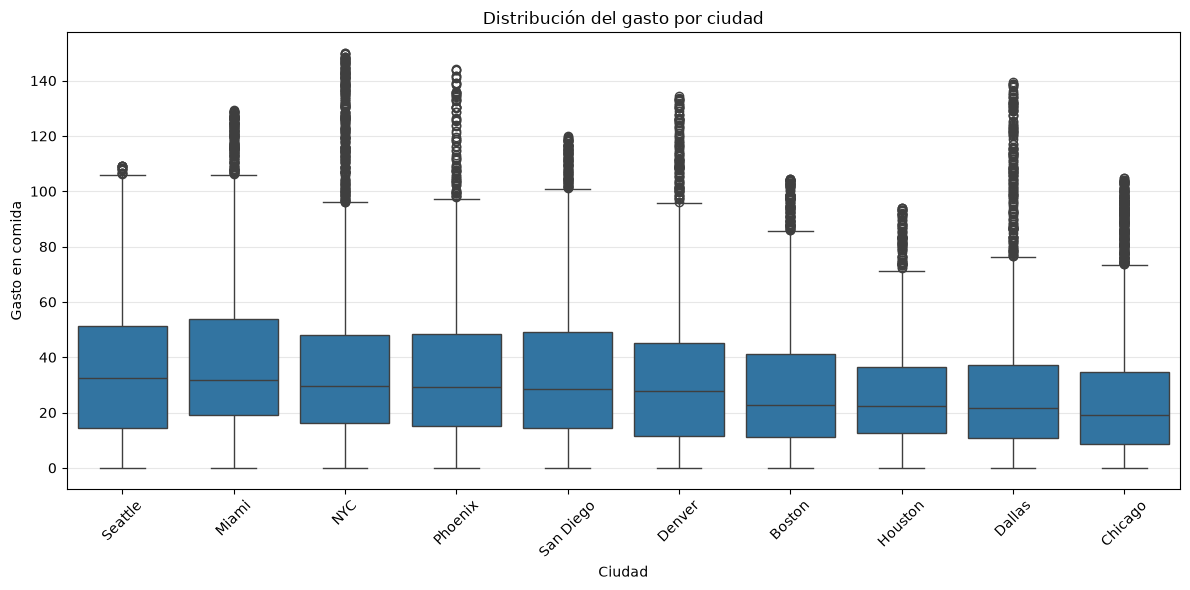

In [27]:
orden_ciudades = (
    df_restaurantes_trans.groupby("ciudad_residencia")["promedio_gasto_comida"]
    .median()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df_restaurantes_trans,
    x="ciudad_residencia",
    y="promedio_gasto_comida",
    order=orden_ciudades
)

plt.title("Distribución del gasto por ciudad")
plt.xlabel("Ciudad")
plt.ylabel("Gasto en comida")

plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [28]:
df_restaurantes_trans.isnull().sum().sort_values(ascending=False)

telefono_contacto            15166
correo_electronico           15072
preferencias_alimenticias     1403
id_persona                       0
nombre                           0
ciudad_residencia                0
apellido                         0
edad                             0
genero                           0
promedio_gasto_comida            0
frecuencia_visita                0
estrato_socioeconomico           0
ocio                             0
membresia_premium                0
consume_licor                    0
tipo_de_pago_mas_usado           0
ingresos_mensuales               0
dtype: int64

In [ ]:
#6. Limpieza de teléfono, correo electrónico y preferencias alimenticias

In [30]:
df_restaurantes_trans[['telefono_contacto', 'correo_electronico']] = (df_restaurantes_trans[['telefono_contacto', 'correo_electronico']].fillna('Dato no brindado'))

In [80]:

df_restaurantes_trans["preferencias_alimenticias"] = (
    df_restaurantes_trans["preferencias_alimenticias"]
    .fillna("Dato no brindado")

)
df_restaurantes_trans.isnull().sum().sort_values(ascending=False)

id_persona                   0
nombre                       0
apellido                     0
edad                         0
genero                       0
ciudad_residencia            0
estrato_socioeconomico       0
frecuencia_visita            0
promedio_gasto_comida        0
ocio                         0
consume_licor                0
preferencias_alimenticias    0
membresia_premium            0
telefono_contacto            0
correo_electronico           0
tipo_de_pago_mas_usado       0
ingresos_mensuales           0
dtype: int64

### LIMPIEZA DE DATOS EXITOSA

#7. Integración con la API de Yelp

In [ ]:
#MIAMI CITY

In [46]:
df_yelp_vf = pd.read_csv(
    r"C:\Users\magri\Downloads\yelp_miami.csv"
)

In [47]:
df_yelp_vf = pd.read_csv(
    r"C:\Users\magri\Downloads\yelp_miami_completo.csv"
)

In [ ]:
#8. Análisis de restaurantes especializados en carnes

In [82]:
print("Cantidad de restaurantes de carnes:", len(restaurantes_carnes))

Cantidad de restaurantes de carnes: 36


In [65]:
#  9.1 Top 5 steakhauses por rating 'Miami'
steakhouses = restaurantes_carnes[
    restaurantes_carnes["title"].str.contains(
        "Steakhouse",
        case=False,
        na=False
    )
]

display(
    steakhouses[
        ["name", "title", "rating", "review_count"]
    ].sort_values(
        by=["rating", "review_count"],
        ascending=[False, False]
    ).head(5)
)

,name,title,rating,review_count
218,Manny's Wood Grill Steakhouse,Steakhouses,4.6,297
389,Ossobuco Miami- Steak house,Steakhouses,4.6,163
56,COTE Miami,Steakhouses,4.5,1041
34,Capriccio,Steakhouses,4.5,192
249,Chop Steakhouse & Bar,Steakhouses,4.4,171


In [66]:
#9.2 Top 5 por cantidad de reviews
top_5_reviews = steakhouses[
    ["name", "title", "rating", "review_count"]
].sort_values(
    by="review_count",
    ascending=False
).head(5)

display(top_5_reviews)

,name,title,rating,review_count
188,Toro Toro,Steakhouses,4.2,1444
56,COTE Miami,Steakhouses,4.5,1041
117,Gordon Ramsay Hell's Kitchen,Steakhouses,4.0,654
314,Perry's Steakhouse & Grille - Coral Gables,Steakhouses,4.0,588
379,La Rosa Fine Cuban Cuisine,Steakhouses,4.1,542


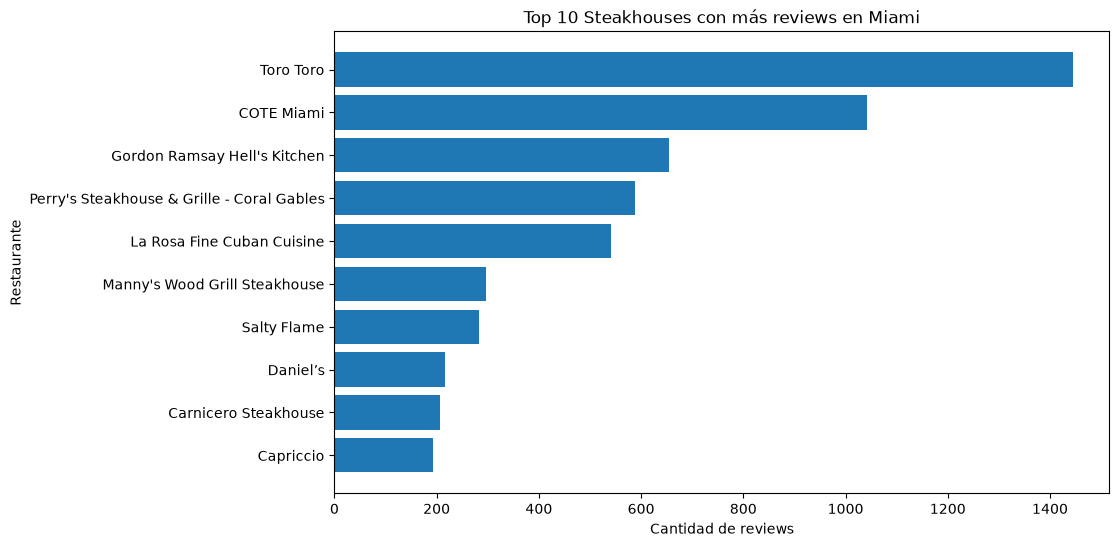

In [69]:
#9.3 Gráfico de los 10 steakhouses con más reviews
top_10_reviews = steakhouses.sort_values(
    by="review_count",
    ascending=False
).head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_10_reviews["name"],
    top_10_reviews["review_count"]
)

plt.xlabel("Cantidad de reviews")
plt.ylabel("Restaurante")
plt.title("Top 10 Steakhouses con más reviews en Miami")

plt.gca().invert_yaxis()
plt.show()

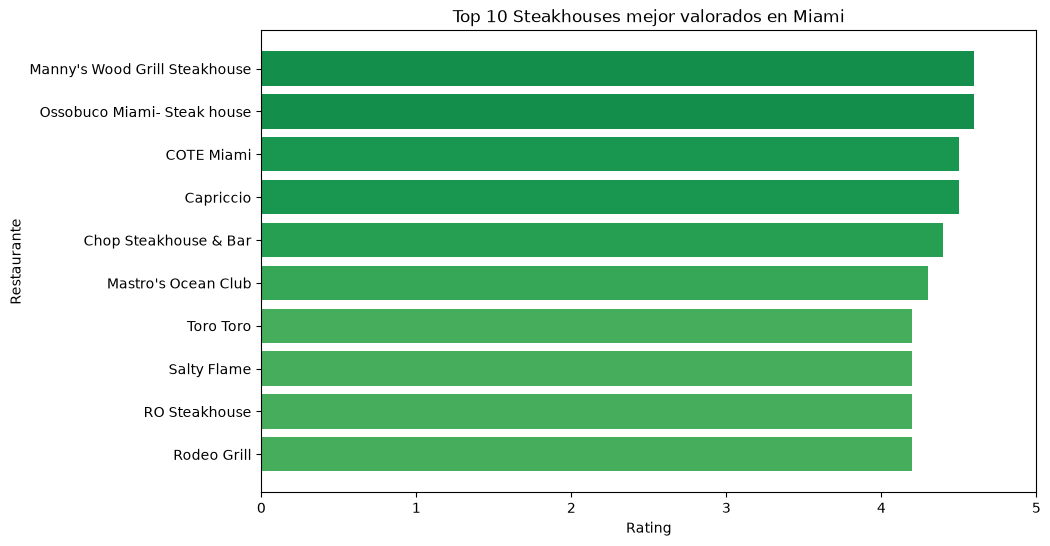

In [72]:
top_10_steak = steakhouses.sort_values(
    by=["rating", "review_count"],
    ascending=[False, False]
).head(10)

plt.figure(figsize=(10, 6))

colores = plt.cm.RdYlGn(
    top_10_steak["rating"] / 5
)

plt.barh(
    top_10_steak["name"],
    top_10_steak["rating"],
    color=colores
)

plt.xlabel("Rating")
plt.ylabel("Restaurante")
plt.title("Top 10 Steakhouses mejor valorados en Miami")

plt.xlim(0, 5)
plt.gca().invert_yaxis()

plt.show()

In [73]:
steakhouses = steakhouses.copy()

steakhouses["score_competitivo"] = (
    steakhouses["rating"] *
    np.log1p(steakhouses["review_count"])
)

In [81]:
#9.4 Metrica 'calidad y popularidad'
ranking_competencia = steakhouses.sort_values(
    by="score_competitivo",
    ascending=False
).head(10)

display(
    ranking_competencia[
        ["name", "rating", "review_count", "score_competitivo"]
    ]
)

,name,rating,review_count,score_competitivo
56,COTE Miami,4.5,1041,31.270038
188,Toro Toro,4.2,1444,30.558631
218,Manny's Wood Grill Steakhouse,4.6,297,26.206630
117,Gordon Ramsay Hell's Kitchen,4.0,654,25.938541
379,La Rosa Fine Cuban Cuisine,4.1,542,25.818148
314,Perry's Steakhouse & Grille - Coral Gables,4.0,588,25.513705
7,Salty Flame,4.2,282,23.710877
34,Capriccio,4.5,192,23.682106
389,Ossobuco Miami- Steak house,4.6,163,23.459386
249,Chop Steakhouse & Bar,4.4,171,22.648976
